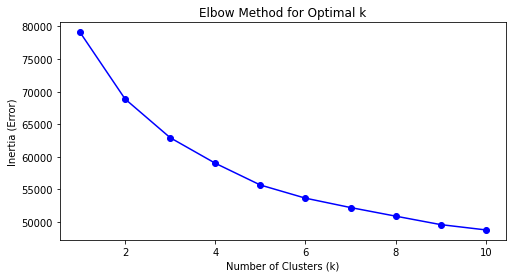

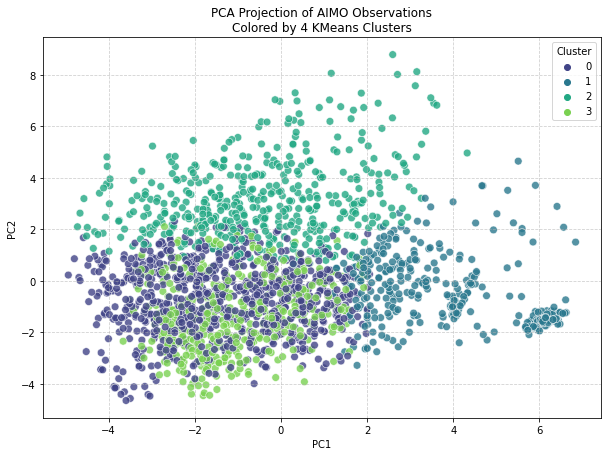


--- Cluster Profiles (Top Features per Cluster) ---

Cluster 0 Characteristics:
No_23_NASM_Deviation     0.697361
No_19_NASM_Deviation     0.697326
No_20_NASM_Deviation     0.689603
No_11_Angle_Deviation    0.689443
No_21_NASM_Deviation     0.689392
Name: 0, dtype: float64

Cluster 1 Characteristics:
No_12_NASM_Deviation     0.844227
No_11_NASM_Deviation     0.837491
No_5_NASM_Deviation      0.837013
No_13_Angle_Deviation    0.837013
No_4_NASM_Deviation      0.834107
Name: 1, dtype: float64

Cluster 2 Characteristics:
No_19_NASM_Deviation     0.796101
No_11_Angle_Deviation    0.793237
No_8_Angle_Deviation     0.778538
No_8_NASM_Deviation      0.773338
No_21_NASM_Deviation     0.759384
Name: 2, dtype: float64

Cluster 3 Characteristics:
No_7_Angle_Deviation    0.731352
No_2_NASM_Deviation     0.731352
No_19_NASM_Deviation    0.728099
No_7_NASM_Deviation     0.726326
No_5_Angle_Deviation    0.720519
Name: 3, dtype: float64

--- PCA Loadings (What do PC1 and PC2 represent?) ---
Top contr

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# --- 1. Load and Clean Data ---
data_path = "../../data/AimoScore_WeakLink_big_scores_A2.csv"
df = pd.read_csv(data_path, index_col=0).drop_duplicates()

# Exclude the scores and non-sensor data
# We only want the movement observations (the 38 sensors)
X = df.drop(columns=["AimoScore", "EstimatedScore", "No_1_Time_Deviation", "No_2_Time_Deviation"], errors='ignore')
X = X.select_dtypes(include=[np.number])

# Standardizing is MANDATORY for PCA and KMeans
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 2. Determine Optimal Clusters (Elbow Method) ---
inertia = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Error)')
plt.title('Elbow Method for Optimal k')
plt.show()

# --- 3. Perform Clustering (Using k=4 based on typical AIMO data) ---
k_optimal = 4 
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
X_with_clusters = X.copy()
X_with_clusters['Cluster'] = clusters

# --- 4. Perform PCA ---
pca = PCA(n_components=2)
pca_results = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(data=pca_results, columns=['PC1', 'PC2'])
df_pca['Cluster'] = clusters.astype(str) # String for discrete coloring

# --- 5. Visualization (PCA Scores colored by Clusters) ---
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=df_pca, palette='viridis', s=60, alpha=0.8)
plt.title(f"PCA Projection of AIMO Observations\nColored by {k_optimal} KMeans Clusters")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# --- 6. Interpretation: Feature Importance for Clusters ---
# Calculate the mean of each feature per cluster to see what defines them
cluster_profile = X_with_clusters.groupby('Cluster').mean()
print("\n--- Cluster Profiles (Top Features per Cluster) ---")
for i in range(k_optimal):
    print(f"\nCluster {i} Characteristics:")
    # Show the 5 highest-valued sensors for this cluster
    print(cluster_profile.loc[i].sort_values(ascending=False).head(5))

# --- 7. Interpretation: PCA Loadings ---
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=X.columns)
print("\n--- PCA Loadings (What do PC1 and PC2 represent?) ---")
print("Top contributors to PC1:")
print(loadings['PC1'].abs().sort_values(ascending=False).head(5))

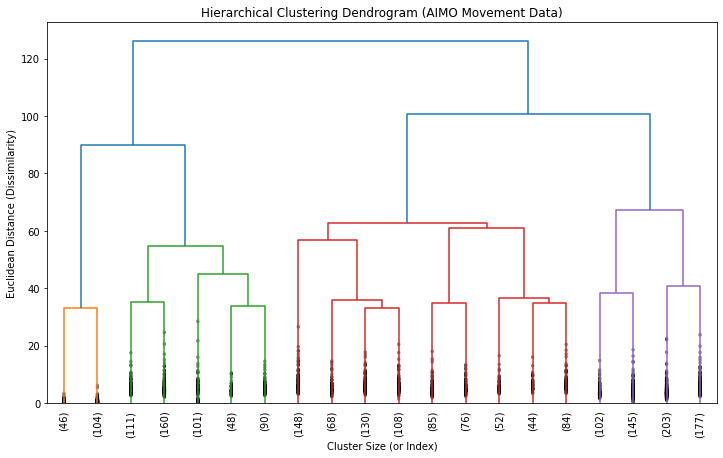

In [2]:
import scipy.cluster.hierarchy as sch
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. Scale the data (Reuse your X from the previous steps)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Create the Linkage Matrix (Using 'ward' to minimize variance, like K-Means)
Z = sch.linkage(X_scaled, method='ward')

# 3. Plot the Dendrogram
plt.figure(figsize=(12, 7))
sch.dendrogram(Z, 
               truncate_mode='lastp',  # Show only the last 'p' merged clusters
               p=20,                   # Show top 20 nodes for readability
               leaf_rotation=90.,
               leaf_font_size=10.,
               show_contracted=True)

plt.title('Hierarchical Clustering Dendrogram (AIMO Movement Data)')
plt.xlabel('Cluster Size (or Index)')
plt.ylabel('Euclidean Distance (Dissimilarity)')

# Draw a horizontal line to show where 4 clusters would be
plt.axhline(y=150, color='r', linestyle='--') # Adjust y-value based on your plot height
plt.show()